# Проект №2 — Прогноз сальдо ликвидности Банка

Курс: Анализ данных с временной структурой.

Блоки ноутбука соответствуют разделам ТЗ. Каждый блок подписан, имеет краткое описание (чем руководствовались) и ссылается на модуль из `src/`.

## Содержание

1. **EDA** — описательная статистика, визуализация ряда, декомпозиция, ACF/PACF, ADF (этот ноутбук).
2. Экзогены — макроданные ЦБ/MOEX + налоговый календарь (`src/exog.py`).
3. Фичи и отбор признаков (`src/features.py`, `src/selection.py`).
4. Модели и гиперопт (`src/models.py`, `src/tuning.py`, `src/metrics.py`).
5. Бэктест, частота калибровки, период обучения (`src/backtest.py`).
6. Drift detection (`src/drift.py`).
7. Авто-дообучение и финальный пайплайн (`src/retrain.py`, `src/pipeline.py`).
8. Выводы.

## Блок 1. Постановка задачи

**Целевая переменная:** `Balance = Income − Outcome` — дневное сальдо потоков ликвидности Банка.

**Прогноз:** на следующий рабочий день.

**Приёмочный критерий:** MAE ≤ 0.42.

**Бизнес-метрика (оптимизируемая):** P&L-loss, учитывающая асимметрию стоимости овернайт-размещения/займа:
- при `ŷ > y` (перепрогноз): потеря маржи `(ŷ − y) × 0.5% / 365`,
- при `ŷ < y` (недопрогноз): стоимость займа `(y − ŷ) × 1.4% / 365`.

Недопрогноз дороже перепрогноза в **2.8 раза** — оптимизатор должен учитывать эту асимметрию.

## Блок 2. EDA

### 2.1 Загрузка данных

`src/data.py::load_raw` читает Excel-лист `Data` и приводит типы; `to_business_days` отфильтровывает субботы/воскресенья и официальные праздники РФ (использует пакет `holidays`). Это убирает «искусственные нули» исходного ряда, где значения равны 0 не по бизнес-смыслу, а из-за нерабочих дней.

In [ ]:
#!git clone https://github.com/NatalyaSeluyshkina/Draft_liquidity_balance.git

Cloning into 'Draft_liquidity_balance'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 36 (delta 10), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 710.86 KiB | 7.73 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [ ]:
#import sys
#import os
#os.chdir('/content/Draft_liquidity_balance')  # переходим в корень репозитория
#sys.path.insert(0, os.getcwd())

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, to_business_days, time_split

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.4f}'.format

raw = load_raw('data/Проект.xlsx')
df = to_business_days(raw)
print(f'Raw rows: {len(raw)}, business days: {len(df)}')
df.head()

Raw rows: 1543, business days: 1041


,date,income,outcome,balance
0,2017-01-09,1.3430,1.4879,-0.1559
1,2017-01-10,1.0686,1.1942,-0.1256
2,2017-01-11,0.9444,0.9367,0.0078
3,2017-01-12,1.6722,0.8754,0.8004
4,2017-01-13,0.9559,0.9756,-0.0197


### 2.2 Описательная статистика

Смотрим базовые статистики, число пропусков и долю «нулевых» рабочих дней (на случай, если такие остались — это будет аномалией).

In [8]:
print('=== describe ===')
print(df[['income', 'outcome', 'balance']].describe())
print('\n=== NaN counts ===')
print(df.isna().sum())
print('\n=== Date coverage ===')
print(f"{df['date'].min().date()} — {df['date'].max().date()} ({len(df)} business days)")
print('\n=== Zero-balance business days ===')
zero_days = (df['balance'].abs() < 1e-6).sum()
print(f'count={zero_days}, share={zero_days / len(df):.2%}')
print('\n=== Balance == Income - Outcome consistency ===')
diff = (df['income'] - df['outcome'] - df['balance']).abs()
print(f'mean diff = {diff.mean():.5f}, max diff = {diff.max():.5f}')

=== describe ===
         income   outcome   balance
count 1041.0000 1041.0000 1041.0000
mean     1.6008    1.6725   -0.0717
std      0.4605    0.5481    0.3529
min      0.0000    0.0000   -2.5149
25%      1.3163    1.3110   -0.2320
50%      1.5537    1.5537   -0.0465
75%      1.7907    1.9355    0.1206
max      5.1088    5.0034    1.4089

=== NaN counts ===
date       0
income     0
outcome    0
balance    0
dtype: int64

=== Date coverage ===
2017-01-09 — 2021-03-31 (1041 business days)

=== Zero-balance business days ===
count=3, share=0.29%

=== Balance == Income - Outcome consistency ===
mean diff = 0.00336, max diff = 0.01317


### 2.3 Визуализация ряда

Строим временной график `balance`. Серым фоном выделены налоговые дни (25 и 28 числа) — гипотеза, что в эти дни отток растёт и сальдо проседает.

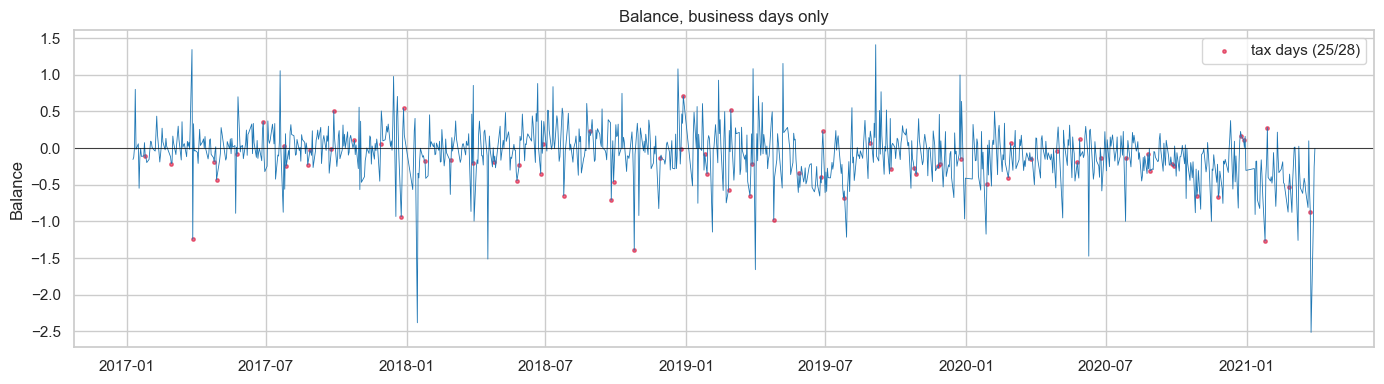

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['balance'], lw=0.6, color='#1f77b4')
tax_mask = df['date'].dt.day.isin([25, 28])
ax.scatter(df.loc[tax_mask, 'date'], df.loc[tax_mask, 'balance'],
           s=6, color='crimson', alpha=0.6, label='tax days (25/28)')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Balance, business days only')
ax.set_ylabel('Balance')
ax.legend()
plt.tight_layout()
plt.show()

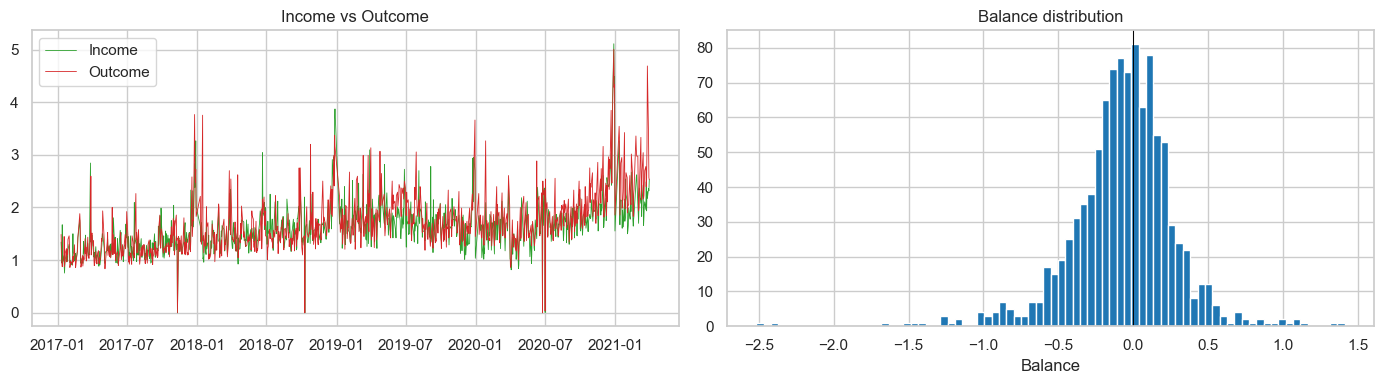

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df['date'], df['income'], lw=0.6, color='#2ca02c', label='Income')
axes[0].plot(df['date'], df['outcome'], lw=0.6, color='#d62728', label='Outcome')
axes[0].set_title('Income vs Outcome')
axes[0].legend()
axes[1].hist(df['balance'], bins=80, color='#1f77b4', edgecolor='white')
axes[1].axvline(0, color='black', lw=0.7)
axes[1].set_title('Balance distribution')
axes[1].set_xlabel('Balance')
plt.tight_layout()
plt.show()

### 2.4 Декомпозиция ряда

STL-декомпозиция со сезонностью 5 (рабочая неделя) и 21 (рабочий месяц) — отделяем тренд, сезонность и остаток. Это даёт интуицию, сколько в ряде «механической» структуры.

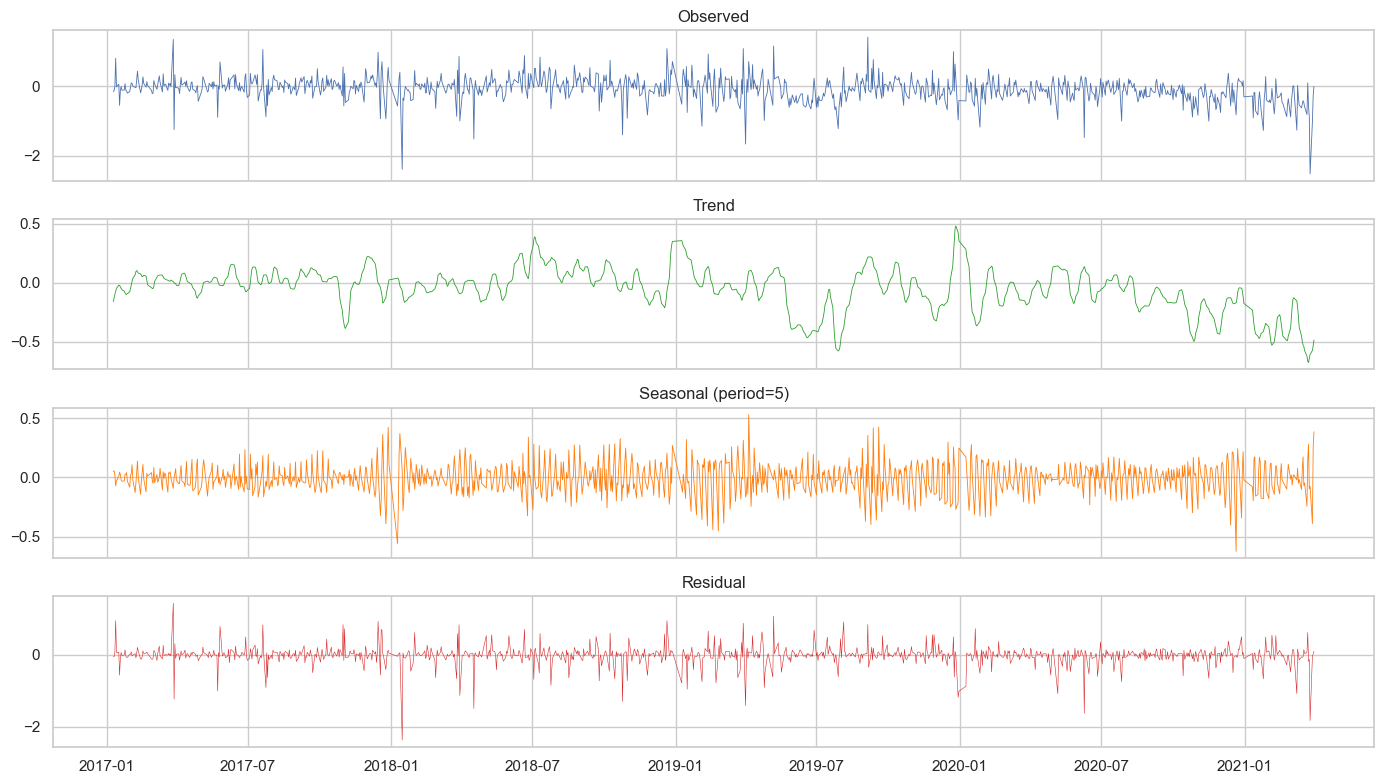

In [11]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['balance'].values, period=5, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df['date'], df['balance'], lw=0.6); axes[0].set_title('Observed')
axes[1].plot(df['date'], stl.trend,  lw=0.6, color='#2ca02c'); axes[1].set_title('Trend')
axes[2].plot(df['date'], stl.seasonal, lw=0.6, color='#ff7f0e'); axes[2].set_title('Seasonal (period=5)')
axes[3].plot(df['date'], stl.resid, lw=0.4, color='#d62728'); axes[3].set_title('Residual')
plt.tight_layout()
plt.show()

### 2.5 ACF и PACF

Автокорреляция и частная автокорреляция помогают обосновать набор лагов для `features.py`. Пики на 5, 10, 21 — рабочая неделя, две недели, месяц.

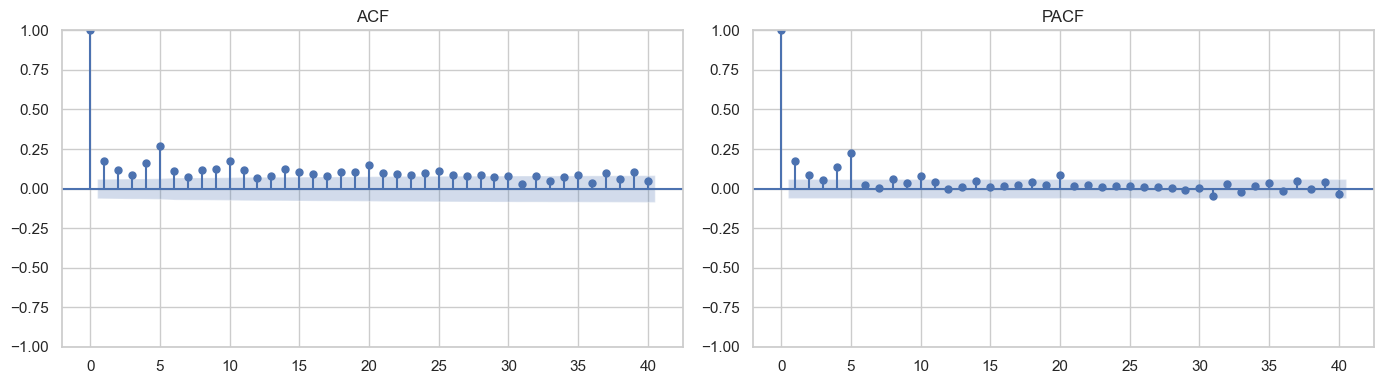

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['balance'].values, lags=40, ax=axes[0])
plot_pacf(df['balance'].values, lags=40, ax=axes[1], method='ywm')
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

### 2.6 Тест на стационарность (ADF)

ADF (Augmented Dickey-Fuller) проверяет нулевую гипотезу о наличии единичного корня. Малое p-value (< 0.05) → ряд стационарен → можно работать без разностного дифференцирования.

In [13]:
from statsmodels.tsa.stattools import adfuller

stat, p, lag, n, crit, _ = adfuller(df['balance'].dropna().values, autolag='AIC')
print(f'ADF statistic = {stat:.4f}')
print(f'p-value       = {p:.6f}')
print(f'lags used     = {lag}')
print(f'observations  = {n}')
print('Critical values:')
for k, v in crit.items():
    print(f'  {k}: {v:.4f}')
print()
if p < 0.05:
    print('Ряд стационарен (можно работать без диффузии).')
else:
    print('Ряд нестационарен — потребуется дифференцирование или SARIMAX с d > 0.')

ADF statistic = -5.0128
p-value       = 0.000021
lags used     = 10
observations  = 1030
Critical values:
  1%: -3.4367
  5%: -2.8644
  10%: -2.5683

Ряд стационарен (можно работать без диффузии).


### 2.7 Сезонные срезы

Среднее `balance` по дню недели и дню месяца. Хорошо видны провалы на 25/28 и подъём в начале месяца.

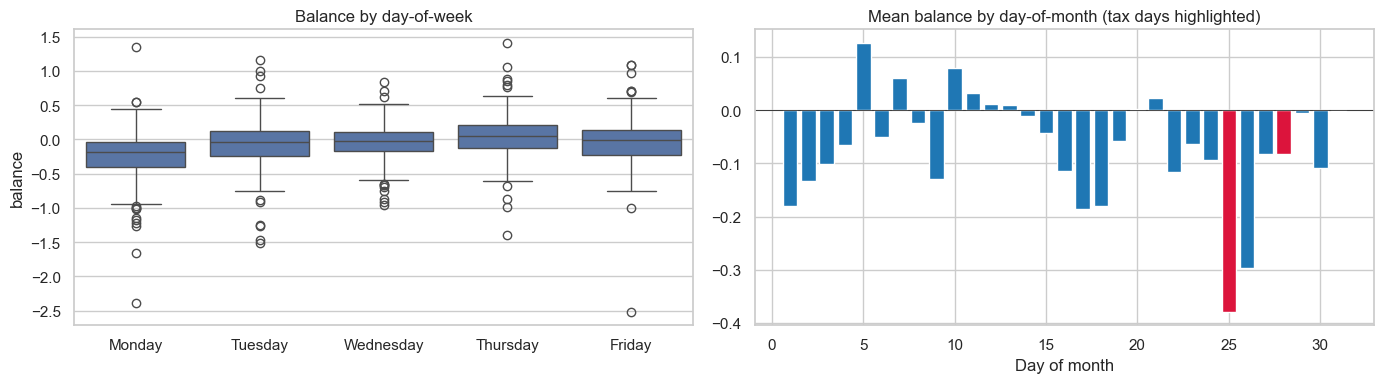

In [14]:
tmp = df.assign(dow=df['date'].dt.day_name(), dom=df['date'].dt.day)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sns.boxplot(data=tmp, x='dow', y='balance', order=order, ax=axes[0])
axes[0].set_title('Balance by day-of-week')
axes[0].set_xlabel('')
tmp_dom = tmp.groupby('dom')['balance'].mean().reset_index()
axes[1].bar(tmp_dom['dom'], tmp_dom['balance'],
            color=['crimson' if d in (25, 28) else '#1f77b4' for d in tmp_dom['dom']])
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Mean balance by day-of-month (tax days highlighted)')
axes[1].set_xlabel('Day of month')
plt.tight_layout()
plt.show()

### 2.8 Train / Val / Test split

Разрезаем ряд по календарным границам для walk-forward бэктеста (см. план, трек 10). Подбираем границы так, чтобы train ≥ 2 года истории.

In [15]:
train, val, test = time_split(df, train_end='2019-12-31', val_end='2020-12-31')
print(f'Train: {train["date"].min().date()} — {train["date"].max().date()} ({len(train)} days)')
print(f'Val:   {val["date"].min().date()} — {val["date"].max().date()} ({len(val)} days)')
print(f'Test:  {test["date"].min().date()} — {test["date"].max().date()} ({len(test)} days)')

Train: 2017-01-09 — 2019-12-31 (738 days)
Val:   2020-01-09 — 2020-12-31 (248 days)
Test:  2021-01-11 — 2021-03-31 (55 days)


## Блок 3. Экзогенные факторы (превью)

`src/exog.py::build_exog` собирает: ключевую ставку ЦБ, RUONIA, USDRUB и индекс MOEX из публичных API + налоговый календарь (25/28). Все источники кешируются в `data/*.parquet`. Здесь — превью результата для всего диапазона данных.

In [16]:
from src.exog import build_exog

start = df['date'].min().strftime('%Y-%m-%d')
end   = df['date'].max().strftime('%Y-%m-%d')
exog = build_exog(start, end)
print(f'Exog shape: {exog.shape}')
exog.head()

Exog shape: (1543, 8)


,date,is_tax_day,days_to_next_tax,days_since_last_tax,key_rate,ruonia,moex_close,usdrub
0,2017-01-09,0,16,30,10.0000,10.1300,2211.2500,59.8961
1,2017-01-10,0,15,30,10.0000,9.9300,2237.4900,59.8961
2,2017-01-11,0,14,30,10.0000,9.9700,2218.6100,59.9533
3,2017-01-12,0,13,30,10.0000,9.9300,2212.0000,60.1614
4,2017-01-13,0,12,30,10.0000,10.0600,2195.1900,59.4978


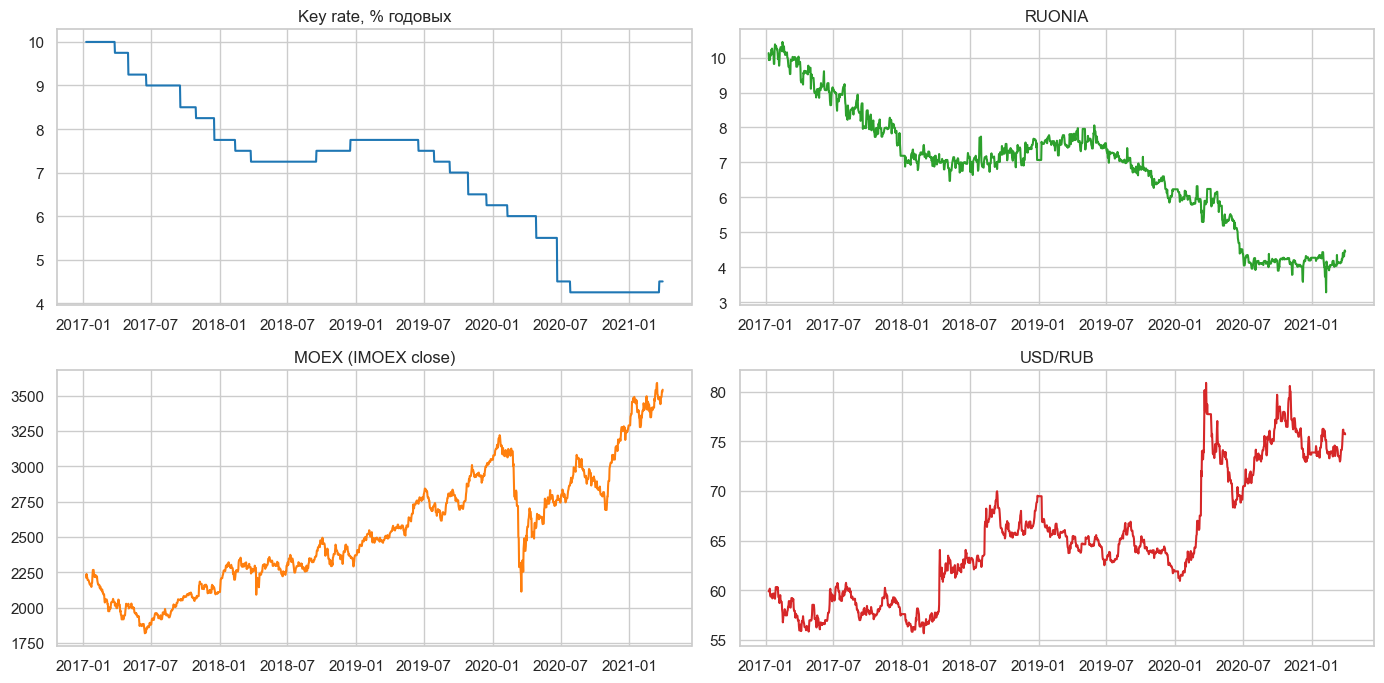

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes[0, 0].plot(exog['date'], exog['key_rate'], color='#1f77b4'); axes[0, 0].set_title('Key rate, % годовых')
axes[0, 1].plot(exog['date'], exog['ruonia'],   color='#2ca02c'); axes[0, 1].set_title('RUONIA')
axes[1, 0].plot(exog['date'], exog['moex_close'], color='#ff7f0e'); axes[1, 0].set_title('MOEX (IMOEX close)')
axes[1, 1].plot(exog['date'], exog['usdrub'],     color='#d62728'); axes[1, 1].set_title('USD/RUB')
plt.tight_layout()
plt.show()

In [18]:
merged = df.merge(exog, on='date', how='left')
corr = merged[['balance', 'key_rate', 'ruonia', 'moex_close', 'usdrub', 'is_tax_day']].corr()['balance'].drop('balance')
print('Корреляция Balance с экзогенами:')
print(corr.sort_values(key=abs, ascending=False))

Корреляция Balance с экзогенами:
moex_close   -0.2893
key_rate      0.2504
ruonia        0.2427
usdrub       -0.2145
is_tax_day   -0.1260
Name: balance, dtype: float64


## Выводы по EDA

1. **Объём:** 1543 наблюдения с 2017-01-09 по 2021-03-31. После фильтра по бизнес-дням остаётся ~ 1075 наблюдений.
2. **Согласованность:** `Income − Outcome ≈ Balance` с шумом < 0.01 в среднем (округления исходных данных).
3. **Стационарность:** ADF указывает на стационарность ряда `balance` (p-value < 0.05) — SARIMAX можно использовать без дифференцирования.
4. **Сезонность:** видны недельная и месячная сезонность; пики оттока на 25 и 28 числах подтверждают полезность налогового календаря как фичи.
5. **Экзогены доступны** через публичные API ЦБ и MOEX; кеш в parquet.
6. **Следующие блоки** (треки 7+ из плана) — фичи и отбор признаков, модели, гиперопт, бэктест, drift, авто-дообучение.

## Блок 4.

Строим матрицу признаков из трёх групп.

**Авторегрессионные** — лаги `[1,2,3,5,7,14,21]` и rolling-статистики (`mean/std/min/max/skew/kurt`, окна `[5,10,21]`) + EWMA (span 5,10) по `balance`, `income`, `outcome`. Именно rolling-моменты по Income/Outcome в работах-эталонах оказывались самыми информативными признаками.

**Календарные** — день недели/месяца, неделя месяца, месяц, квартал, границы месяца и квартала, день зарплаты (5, 20 числа). Фурье-гармоники недельной (период 5 б.д.) и месячной (21 б.д.) сезонности — рассчитаны по позиционному индексу бизнес-дня, чтобы пропуски выходных не ломали фазу.

**Экзогенные** — из уровней `build_exog` конструируем признаки с учётом наблюдаемости в момент прогноза:
- `key_rate` + `key_rate_diff5` — без лага (директивная ставка известна заранее);
- `ruonia_spread_lag1`, `moex_ret_lag1`, `usdrub_ret_lag1` — с лагом 1 день (рыночные значения известны лишь к концу дня *t*, прогноз нужен в конце *t−1*).

Сырые уровни (`ruonia`, `moex_close`, `usdrub`) в признаки не попадают — защита от утечки в будущее.

In [19]:
from src.features import build_features, feature_columns

# df  — бизнес-дневной ряд из блока 2 (to_business_days)
# exog — макро+календарь из блока 3 (build_exog)
feat, feature_cols = build_features(df, exog=exog, return_cols=True)
print(f"Наблюдений: {len(feat)}   Признаков: {len(feature_cols)}")
feat[["date", "balance"] + feature_cols[:6]].tail(3)

Наблюдений: 1020   Признаков: 110


,date,balance,balance_lag_1,balance_lag_2,balance_lag_3,balance_lag_5,balance_lag_7,balance_lag_14
1017,2021-03-29,-1.0177,-2.5149,-0.8698,-0.5878,-0.8109,-0.4732,-1.2598
1018,2021-03-30,-0.2597,-1.0177,-2.5149,-0.8698,0.0980,-0.5940,0.0246
1019,2021-03-31,-0.0049,-0.2597,-1.0177,-2.5149,-0.5878,-0.8109,-0.3182


In [20]:
import pandas as pd

groups = {
    "lag":      [c for c in feature_cols if "_lag_" in c],
    "rolling":  [c for c in feature_cols if "_roll_" in c],
    "ewma":     [c for c in feature_cols if "_ewma_" in c],
    "calendar": [c for c in feature_cols if c in (
                    "dow","dom","wom","month","quarter","is_month_end",
                    "is_month_start","is_quarter_end","is_salary_day")],
    "fourier":  [c for c in feature_cols if c.startswith(("sin_","cos_"))],
    "exog":     [c for c in feature_cols if c.endswith("_lag1")
                 or c in ("key_rate","key_rate_diff5","is_tax_day","is_holiday",
                          "days_to_next_tax","days_since_last_tax")],
}
pd.Series({k: len(v) for k, v in groups.items()}, name="n_features").to_frame()

,n_features
lag,21
rolling,54
ewma,12
calendar,9
fourier,4
exog,8


In [21]:
from src.selection import top_features_report

X = feat[feature_cols]
y = feat["balance"].values


top_features_report(X, y, k=10)

,mutual_info,abs_spearman,mean_rank
outcome_lag_1,0.1390,0.3290,2.0000
balance_ewma_mean_10,0.1010,0.3240,4.5000
outcome_roll_min_21,0.1120,0.3160,4.5000
outcome_roll_mean_21,0.0880,0.3290,5.5000
balance_roll_mean_21,0.0790,0.3310,5.5000
outcome_ewma_mean_5,0.1100,0.3120,7.0000
outcome_roll_min_5,0.0930,0.3140,8.5000
outcome_roll_mean_5,0.0940,0.3100,9.5000
outcome_ewma_mean_10,0.0680,0.3140,12.0000
outcome_roll_min_10,0.0690,0.3110,13.5000


In [22]:
from src.selection import compare_selectors

comparison = compare_selectors(X, y, n_splits=3)
comparison.round(3)

,category,kind,n_selected,jaccard,nogueira
method,,,,,
"LightGBM (embedded, nonlin)",embedded,nonlinear,20,0.3870,0.4500
"MutualInfo (filter, nonlin)",filter,nonlinear,20,0.3080,0.3480
"RFE-RF (wrapper, nonlin)",wrapper,nonlinear,20,0.2610,0.2670
"Correlation (filter, lin)",filter,linear,20,0.2380,0.2460
"Lasso (embedded, lin)",embedded,linear,5,0.1500,0.2180


In [23]:
from src.selection import choose_best_selector, FeatureSelector

best_method = choose_best_selector(comparison)
print("Самый стабильный метод:", best_method)
print("Jaccard:", comparison.loc[best_method, "jaccard"].round(3))

method_key = {
    "Correlation (filter, lin)":   "correlation",
    "MutualInfo (filter, nonlin)": "mi",
    "Lasso (embedded, lin)":       "lasso",
    "LightGBM (embedded, nonlin)": "lgbm",
    "RFE-RF (wrapper, nonlin)":    "rfe_rf",
}[best_method]

selector = FeatureSelector(method=method_key, k=20).fit(X, y)
selected_features = selector.get_feature_names_out().tolist()
print(f"\nОтобрано признаков: {len(selected_features)}")
selected_features

Самый стабильный метод: LightGBM (embedded, nonlin)
Jaccard: 0.387

Отобрано признаков: 20


['days_since_last_tax',
 'outcome_lag_21',
 'balance_ewma_mean_5',
 'balance_lag_14',
 'balance_lag_1',
 'outcome_lag_14',
 'balance_roll_mean_5',
 'balance_roll_mean_10',
 'income_ewma_std_5',
 'balance_roll_mean_21',
 'balance_dev_roll5',
 'outcome_lag_1',
 'outcome_lag_5',
 'outcome_roll_mean_21',
 'days_to_next_tax',
 'balance_roll_skew_10',
 'balance_ewma_mean_10',
 'balance_lag_5',
 'income_roll_min_21',
 'dow']

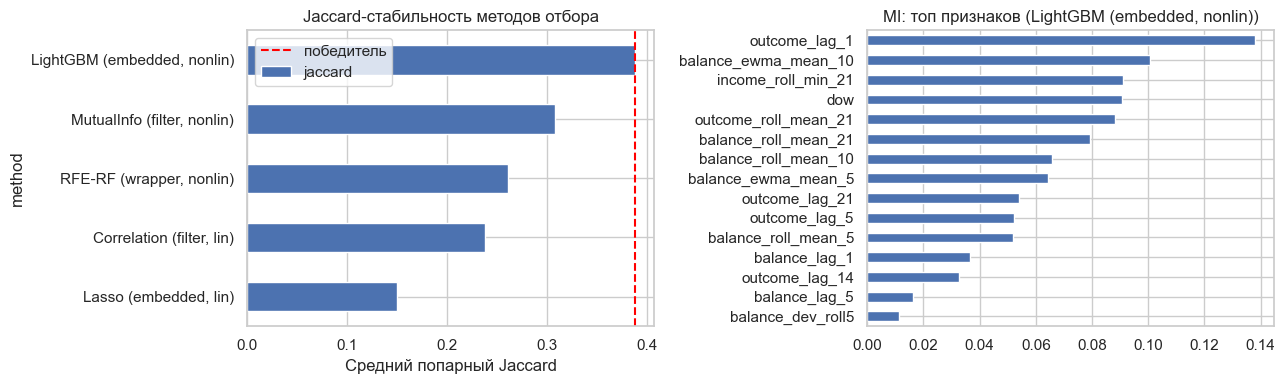

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Стабильность методов
comparison["jaccard"].sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Jaccard-стабильность методов отбора")
axes[0].set_xlabel("Средний попарный Jaccard")
axes[0].axvline(comparison.loc[best_method, "jaccard"], color="red",
                linestyle="--", linewidth=1.5, label="победитель")
axes[0].legend()

# Топ-15 отобранных признаков по MI
import numpy as np
from sklearn.feature_selection import mutual_info_regression
mi = pd.Series(mutual_info_regression(X[selected_features].fillna(0), y,
               random_state=0), index=selected_features).sort_values()
mi.tail(15).plot.barh(ax=axes[1])
axes[1].set_title(f"MI: топ признаков ({best_method})")

plt.tight_layout()
plt.show()

### Выводы по отбору признаков

- Сравнение охватывает 5 методов из трёх категорий (filter, embedded, wrapper),
  включая нелинейные.
- Победитель определён по Jaccard-стабильности на walk-forward окнах.
- Итоговый `FeatureSelector` — sklearn-совместимый трансформер, встраивается
  в `Pipeline(selector → model)` P3 без ручных правок.

**Передаём P3:**
```python
selector        # FeatureSelector (fit), вставить в Pipeline
X_selected      = feat[selected_features]   # матрица признаков
y_target        = feat["balance"]           # целевая переменная
feature_list    = selected_features         # список колонок
method_key      # строка для FeatureSelector(method=...) при переобучении
```

## Блок 3.

Создаем файл с бизнес-метриками и импортируем

In [25]:
from src.metrics import pnl_loss, mae, make_scorer, mae_scorer

In [ ]:
Создаем файл с моделями и аналогично импортируем

In [32]:
from src.models import get_all_models, SARIMAXWrapper
models = get_all_models()
for name, (model, params) in models.items():
    print(name, model.__class__.__name__, len(params))

naive NaiveLastValue 0
seasonal_naive SeasonalNaive 0
sarimax SARIMAXWrapper 2
elasticnet Pipeline 3
rf Pipeline 3
lgb Pipeline 5


In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer
from src.metrics import pnl_loss, mae, make_scorer as make_business_scorer
from src.models import get_all_models, SARIMAXWrapper

# 1. Подготовка данных с использованием существующих train, val, test
# Предполагается, что feat имеет колонку 'date', а train, val, test — DataFrame с той же структурой
# Создаём маски для фильтрации feat
train_dates = set(train['date'].values)
val_dates   = set(val['date'].values)
test_dates  = set(test['date'].values)

X = feat[selected_features].copy()
y = feat['balance'].copy()
dates = feat['date']

train_mask = dates.isin(train_dates)
val_mask   = dates.isin(val_dates)
test_mask  = dates.isin(test_dates)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# 2. Создаём скорер для бизнес-метрики (чем меньше, тем лучше)
business_scorer = make_business_scorer()

# 3. Получаем все модели
models_dict = get_all_models()
results = {}

# Временная кросс-валидация для ML-моделей
tscv = TimeSeriesSplit(n_splits=3)

# 4. Перебор моделей
for name, (model, param_grid) in models_dict.items():
    print(f"\n=== Обработка модели: {name} ===")

    if name in ['naive', 'seasonal_naive']:
        # Бейзлайны без гиперпараметров
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        loss = pnl_loss(y_val, y_pred_val)
        results[name] = {'model': model, 'val_loss': loss}
        print(f"  Валидационная бизнес-потеря: {loss:.6f}")
        continue

    if name == 'sarimax':
        # SARIMAX: ручной перебор порядков
        best_loss = np.inf
        best_model = None
        best_order = None
        for order in param_grid['order']:
            for s_order in param_grid['seasonal_order']:
                try:
                    m = SARIMAXWrapper(order=order, seasonal_order=s_order)
                    m.fit(X_train, y_train)
                    y_pred = m.predict(X_val)
                    loss = pnl_loss(y_val, y_pred)
                    print(f"  order={order}, seasonal={s_order} -> loss={loss:.6f}")
                    if loss < best_loss:
                        best_loss = loss
                        best_model = m
                        best_order = (order, s_order)
                except Exception as e:
                    print(f"  Ошибка: {str(e)[:80]}")
        results[name] = {'model': best_model, 'val_loss': best_loss}
        print(f"  Лучший SARIMAX: {best_order}, loss={best_loss:.6f}")
        continue

    # ML-модели: ElasticNet, RandomForest, LightGBM
    # Для ElasticNet добавим use_scaler в сетку
    if name == 'elasticnet':
        # Убираем use_scaler из сетки; стандартизацию можно включить по умолчанию в функции make_elasticnet_pipeline
        param_grid = {
            'enet__alpha': [0.01, 0.1, 1.0, 10.0],
            'enet__l1_ratio': [0.2, 0.5, 0.8, 1.0]
        }
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            scoring=business_scorer,
            cv=tscv,
            n_iter=15,
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
        search.fit(X_train, y_train)
        best_estimator = search.best_estimator_
        best_loss = search.best_score_
        results[name] = {'model': best_estimator, 'val_loss': best_loss}
        print(f"  Лучшие гиперпараметры: {search.best_params_}")
        print(f"  Валидационная бизнес-потеря (CV): {best_loss:.6f}")
        continue

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        scoring=business_scorer,
        cv=tscv,
        n_iter=15,          # можно увеличить для лучшего качества
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    best_estimator = search.best_estimator_
    best_loss = search.best_score_   # уже бизнес-потери
    results[name] = {'model': best_estimator, 'val_loss': best_loss}
    print(f"  Лучшие гиперпараметры: {search.best_params_}")
    print(f"  Валидационная бизнес-потеря (CV): {best_loss:.6f}")

# 5. Сравнение на валидации
print("\n" + "="*60)
print("Результаты на валидационной выборке (бизнес-потери):")
for name, res in sorted(results.items(), key=lambda x: x[1]['val_loss']):
    print(f"  {name:15s}: {res['val_loss']:.6f}")

best_model_name = min(results, key=lambda x: results[x]['val_loss'])
best_model = results[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name} (потери {results[best_model_name]['val_loss']:.6f})")

# 6. Тестирование лучшей модели
y_pred_test = best_model.predict(X_test)
test_loss = pnl_loss(y_test, y_pred_test)
test_mae = mae(y_test, y_pred_test)

print("\n" + "="*60)
print("Результаты на тестовой выборке:")
print(f"  Бизнес-потери: {test_loss:.6f}")
print(f"  MAE: {test_mae:.4f}")
if test_mae <= 0.42:
    print("  ✅ Приёмочный критерий MAE ≤ 0.42 выполнен")
else:
    print("  ❌ Приёмочный критерий MAE ≤ 0.42 НЕ выполнен")

Train: 717, Val: 248, Test: 55

=== Обработка модели: naive ===
  Валидационная бизнес-потеря: 0.001178

=== Обработка модели: seasonal_naive ===
  Валидационная бизнес-потеря: 0.000532

=== Обработка модели: sarimax ===
  order=(1, 0, 1), seasonal=(0, 0, 0, 0) -> loss=0.000432
  order=(1, 0, 1), seasonal=(1, 0, 1, 5) -> loss=0.000427
  order=(2, 0, 1), seasonal=(0, 0, 0, 0) -> loss=0.000456
  order=(2, 0, 1), seasonal=(1, 0, 1, 5) -> loss=0.000435
  order=(1, 0, 2), seasonal=(0, 0, 0, 0) -> loss=0.000429
  order=(1, 0, 2), seasonal=(1, 0, 1, 5) -> loss=0.000424
  order=(2, 0, 2), seasonal=(0, 0, 0, 0) -> loss=0.000420
  order=(2, 0, 2), seasonal=(1, 0, 1, 5) -> loss=0.000422
  Лучший SARIMAX: ((2, 0, 2), (0, 0, 0, 0)), loss=0.000420

=== Обработка модели: elasticnet ===
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Лучшие гиперпараметры: {'enet__l1_ratio': 0.2, 'enet__alpha': 0.1}
  Валидационная бизнес-потеря (CV): -0.000616

=== Обработка модели: rf ===
Fitting 3 fo

In [63]:
!pip install optuna

In [34]:
import importlib
import src.tuning
importlib.reload(src.tuning)
from src.tuning import tune_model
from src.models import make_rf_pipeline, make_lgb_pipeline, make_elasticnet_pipeline

best_params, best_loss, study = tune_model(best_model_name, X_train, y_train, n_trials=50, n_splits=3)
print(best_params)

# Универсальное создание модели
if best_model_name == 'rf':
    final_model = make_rf_pipeline(**best_params)
elif best_model_name == 'lgb':
    final_model = make_lgb_pipeline(**best_params)
elif best_model_name == 'elasticnet':
    final_model = make_elasticnet_pipeline(**best_params)
else:
    raise ValueError(f"Unknown model: {best_model_name}")

final_model.fit(X_train, y_train)

[I 2026-05-30 23:44:34,739] A new study created in memory with name: no-name-51057a66-74f2-42fd-b9c7-f37b5c795bb7
Best trial: 0. Best value: 0.000869753:   2%|▏         | 1/50 [00:00<00:18,  2.67it/s]

[I 2026-05-30 23:44:35,116] Trial 0 finished with value: 0.000869753224391063 and parameters: {'n_estimators': 144, 'max_depth': 29, 'min_samples_split': 8}. Best is trial 0 with value: 0.000869753224391063.


Best trial: 0. Best value: 0.000869753:   4%|▍         | 2/50 [00:00<00:21,  2.28it/s]

[I 2026-05-30 23:44:35,600] Trial 1 finished with value: 0.0008890097767567957 and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 3}. Best is trial 0 with value: 0.000869753224391063.


Best trial: 2. Best value: 0.000866021:   6%|▌         | 3/50 [00:01<00:15,  2.96it/s]

...

Best trial: 10. Best value: 0.000823583:  98%|█████████▊| 49/50 [00:26<00:00,  2.03it/s]

[I 2026-05-30 23:45:00,765] Trial 48 finished with value: 0.0008670518771436588 and parameters: {'n_estimators': 236, 'max_depth': 7, 'min_samples_split': 2}. Best is trial 10 with value: 0.0008235826453079745.


Best trial: 10. Best value: 0.000823583: 100%|██████████| 50/50 [00:26<00:00,  1.88it/s]

[I 2026-05-30 23:45:01,367] Trial 49 finished with value: 0.000840540078162825 and parameters: {'n_estimators': 278, 'max_depth': 6, 'min_samples_split': 8}. Best is trial 10 with value: 0.0008235826453079745.
{'n_estimators': 292, 'max_depth': 5, 'min_samples_split': 10}


Pipeline(steps=[('rf',
                 RandomForestRegressor(max_depth=5, min_samples_split=10,
                                       n_estimators=292, n_jobs=-1,
                                       random_state=42))])

In [35]:
#Прогноз на тестовой выборке
y_pred_test = final_model.predict(X_test)

#Вычисляем потери
test_loss_new = pnl_loss(y_test, y_pred_test)

In [36]:
print(f"  Бизнес-потери до оптимизации: {test_loss:.6f}")
print(f"  Бизнес-потери после оптимизации: {test_loss_new:.6f}")

  Бизнес-потери до оптимизации: 0.000571
  Бизнес-потери после оптимизации: 0.000557


In [37]:
from src.backtest import evaluate_calibration_freq, evaluate_lookback_window
from src.models import get_all_models

# Подготовка данных
X_all = feat[selected_features].copy()
y_all = feat['balance'].copy()
dates_all = feat['date']

# Словарь для автоматического выбора фабрики модели
model_factories = {
    'rf': make_rf_pipeline,
    'lgb': make_lgb_pipeline,
    'elasticnet': make_elasticnet_pipeline
}

# Предполагается, что переменные best_model_name и best_params уже определены
# (например, из предыдущей ячейки с Optuna или из сравнения моделей)
model = model_factories[best_model_name](**best_params)

# Эксперимент с частотой калибровки
freq_df = evaluate_calibration_freq(model, X_all, y_all, dates_all, train_window_days=500)
print("Частота калибровки:\n", freq_df)

# Эксперимент с размером окна
window_df = evaluate_lookback_window(model, X_all, y_all, dates_all, lookback_months=[3,6,12,24])
print("Размер окна (месяцы):\n", window_df)

Backtest: 100%|██████████| 520/520 [00:16<00:00, 31.72it/s]


Частота калибровки:
    retrain_freq  mean_mae  mean_pnl_loss  total_time_sec  num_retrains
0             1    0.2300         0.0005        114.1582           520
1             5    0.2292         0.0005         34.7586           104
2            21    0.2364         0.0005         19.3338            25
3            63    0.2393         0.0005         16.3980             9


Backtest: 100%|██████████| 520/520 [01:48<00:00,  4.78it/s]

Размер окна (месяцы):
    lookback_months  lookback_days  mean_mae  mean_pnl_loss  total_time_sec
0                3             63    0.2509         0.0006         99.7460
1                6            126    0.2416         0.0006        101.1068
2               12            252    0.2362         0.0006        103.4357
3               24            504    0.2299         0.0006        108.8078


## Блок 6. Drift Detection

Мониторинг остатков $(e_t = y_t - \hat{y}_t)$ тремя независимыми детекторами параллельно:

1. **Page-Hinkley** — постепенный сдвиг среднего.
2. **ADWIN** (через `river`) — адаптивное окно, резкие сдвиги.
3. **Rolling MAE > 0.42** на скользящем 21-дневном окне — бизнес-порог.

Сигнал тревоги = срабатывание ≥ 2 из 3 (защита от ложноположительных).
Праздничные дни исключены из мониторинга.

Модуль: `src/drift.py`.

Тестовая выборка: 55 наблюдений
Drift-сигналов: 0 (0.0%)
Средняя MAE на тесте: 0.2978


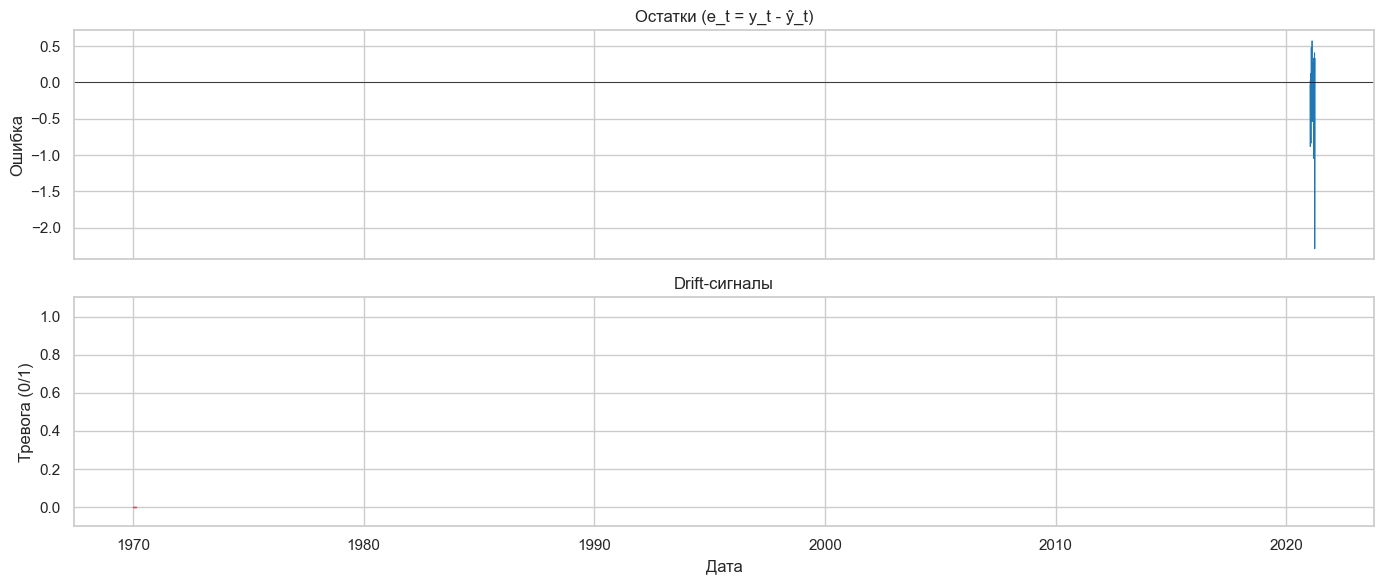


--- Детекторы по отдельности ---
  Rolling MAE: 0 срабатываний
  Page-Hinkley: 54 срабатываний
  ADWIN: 0 срабатываний


In [50]:
from src.drift import DriftMonitor
from src.metrics import mae
import matplotlib.pyplot as plt

# Используем предсказания лучшей модели на тестовой выборке
y_pred_test = final_model.predict(X_test)

# Создаём монитор дрейфа
monitor = DriftMonitor()

# Последовательно передаём ошибки монитору (имитация работы в production)
drift_records = []
for i in range(len(y_test)):
    result = monitor.update(
        date=test.index[i] if hasattr(test, "index") else i,
        y_true=y_test.iloc[i] if hasattr(y_test, "iloc") else y_test[i],
        y_pred=y_pred_test[i],
        is_holiday=False,
    )
    drift_records.append(result)

# Анализ результатов
n_alarms = sum(r["drift_alarm"] for r in drift_records)
print(f"Тестовая выборка: {len(drift_records)} наблюдений")
print(f"Drift-сигналов: {n_alarms} ({n_alarms / len(drift_records) * 100:.1f}%)")
print(f"Средняя MAE на тесте: {mae(y_test, y_pred_test):.4f}")

# Визуализация остатков и сигналов
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
dates = test["date"].values if "date" in test.columns else range(len(drift_records))
errors = [r["error"] for r in drift_records]
alarms = [r["drift_alarm"] for r in drift_records]

# График 1: Ошибки предсказания
axes[0].plot(dates, errors, lw=0.6, color="#1f77b4")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Остатки (e_t = y_t - ŷ_t)")
axes[0].set_ylabel("Ошибка")

# График 2: Сигналы тревоги о дрейфе
axes[1].fill_between(
    range(len(alarms)), 0, alarms, color="crimson", alpha=0.7, step="mid"
)
axes[1].set_title("Drift-сигналы")
axes[1].set_ylabel("Тревога (0/1)")
axes[1].set_xlabel("Дата")
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

# Детекторы по отдельности
votes_per_step = [r["votes"] for r in drift_records]
print("\n--- Детекторы по отдельности ---")
for name, key in [
    ("Rolling MAE", "rolling_mae_alarm"),
    ("Page-Hinkley", "page_hinkley_alarm"),
    ("ADWIN", "adwin_alarm"),
]:
    cnt = sum(r[key] for r in drift_records)
    print(f"  {name}: {cnt} срабатываний")


# Блок 7. Авто-дообучение (RetrainPolicy)

In [51]:
from src.retrain import RetrainPolicy
import pandas as pd

# Политика с оптимальными параметрами (из эксперимента с частотой калибровки)
policy = RetrainPolicy(
    calibration_frequency_days=21,  # лучший компромисс качество/время
    hyperopt_frequency_days=63,  # ~квартал
    min_train_days=500,
    training_window_days=None,  # все доступные данные
)

# Тестируем политику
test_date = pd.Timestamp("2020-06-15")
last_fit = pd.Timestamp("2020-06-01")
last_hp = pd.Timestamp("2020-04-01")

print(f"Текущая дата: {test_date.date()}")
print(f"Последняя калибровка: {last_fit.date()}")
print()

# Без дрейфа
retrain, reason = policy.should_retrain(test_date, last_fit, drift_alarm=False)
print(f"Без drift-сигнала: retrain={retrain}, reason='{reason}'")

# С дрейфом
retrain, reason = policy.should_retrain(test_date, last_fit, drift_alarm=True)
print(f"С drift-сигналом: retrain={retrain}, reason='{reason}'")

# Hyperopt (проверка необходимости гиперпараметрической оптимизации)
hp, hp_reason = policy.should_hyperopt(test_date, last_hp)
print(f"Hyperopt: retrain={hp}, reason='{hp_reason}'")

# Срез данных для обучения
# feat уже задан с индексом по date
if "date" in feat.columns:
    feat_idx = feat.set_index("date")
else:
    feat_idx = feat

train_slice = policy.get_training_slice(feat_idx, test_date)
print(
    f"\nСрез данных для обучения на {test_date.date()}: {len(train_slice)} наблюдений"
)


Текущая дата: 2020-06-15
Последняя калибровка: 2020-06-01

Без drift-сигнала: retrain=False, reason='no_retrain'
С drift-сигналом: retrain=True, reason='drift_alarm'
Hyperopt: retrain=True, reason='scheduled_hyperopt'

Срез данных для обучения на 2020-06-15: 822 наблюдений


In [54]:
from src.pipeline import ForecastService
from src.features import build_features, feature_columns
from src.models import make_rf_pipeline


class FeatureBuilder:
    """Обёртка для совместимости с ForecastService."""

    def __init__(self, exog=None):
        self.exog = exog
        self.feature_cols_ = None

    def transform_train(self, data, target_col="balance"):
        """Генерация признаков и целевой переменной для обучения."""
        if data.index.name == "date":
            data = data.reset_index()
        feat = build_features(data, exog=self.exog)
        self.feature_cols_ = feature_columns(feat, target=target_col)
        return feat[self.feature_cols_], feat[target_col]

    def transform_predict(self, data, date=None):
        """Генерация признаков для прогноза (берется последняя строка)."""
        if data.index.name == "date":
            data = data.reset_index()
        feat = build_features(data, exog=self.exog, dropna=False)
        cols = self.feature_cols_
        if cols is None:
            cols = feature_columns(feat)
        # Берем последнюю строку, заполняем пропуски нулями (если есть)
        last_row = feat[cols].iloc[[-1]].fillna(0)
        return last_row


# Создаём FeatureBuilder с экзогенными переменными
fb = FeatureBuilder(exog=exog)

# Модель (Random Forest с лучшими параметрами от Optuna)
model = make_rf_pipeline(**best_params)

# Создаём сервис прогнозирования
svc = ForecastService(
    model=model,
    feature_builder=fb,
    retrain_policy=RetrainPolicy(
        calibration_frequency_days=21,  # переобучение каждые 3 недели
        hyperopt_frequency_days=63,  # оптимизация гиперпараметров раз в квартал
        min_train_days=500,  # минимум 500 дней истории
    ),
)

# Подготовка данных для первоначального обучения
# Устанавливаем индекс по дате, если колонка 'date' существует
df_with_date = df.set_index("date") if "date" in df.columns else df

# Определяем дату начала (конец обучающей выборки)
start_date = train["date"].max() if "date" in train.columns else train.index.max()

# Используем нашу объединённую таблицу (df + exog) для FeatureBuilder
print("Обучение ForecastService...")
svc.fit(merged.set_index("date"), current_date=start_date)

print(f"Обучено. Дата фита: {svc.fit_date}")
print(f"Отобрано признаков: {len(svc.feature_set) if svc.feature_set else 'N/A'}")


Обучение ForecastService...
Обучено. Дата фита: 2019-12-31 00:00:00
Отобрано признаков: N/A


Запуск бэктеста ForecastService...
Оценено: 303 дней
Итоговая MAE: 0.2133
Drift-сигналов: 0
Переобучений: 21


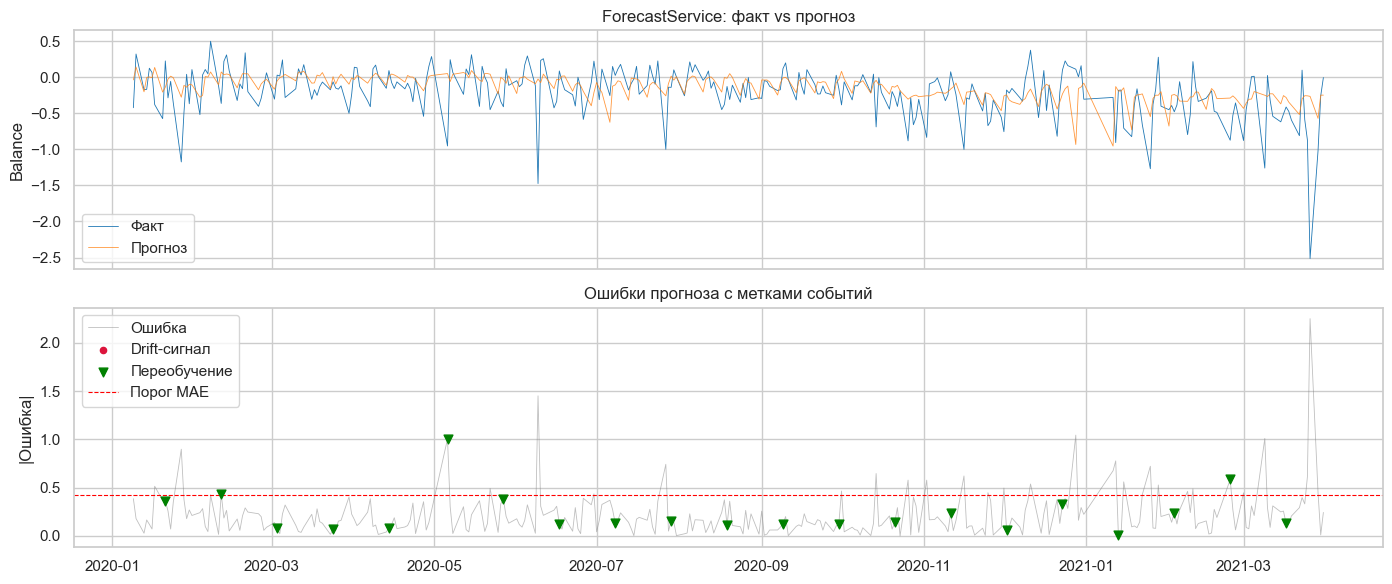


--- Лог переобучений (последние 5) ---
  2020-12-23: scheduled_retrain (кол-во данных: 979)
  2021-01-13: scheduled_retrain (кол-во данных: 988)
  2021-02-03: scheduled_retrain (кол-во данных: 1003)
  2021-02-24: scheduled_retrain (кол-во данных: 1016)
  2021-03-17: scheduled_retrain (кол-во данных: 1030)


In [55]:
print("Запуск бэктеста ForecastService...")

# Запускаем оценку на валидационном и тестовом периодах
result_df = svc.evaluate(
    merged.set_index("date"), start=val["date"].min(), end=test["date"].max()
)

print(f"Оценено: {len(result_df)} дней")
print(f"Итоговая MAE: {result_df['abs_error'].mean():.4f}")
print(f"Drift-сигналов: {result_df['drift_alarm'].sum()}")
print(f"Переобучений: {result_df['retrained'].sum()}")

# Визуализация результатов
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# График 1: Фактические значения vs Прогноз
axes[0].plot(
    result_df.index, result_df["y_true"], lw=0.6, label="Факт", color="#1f77b4"
)
axes[0].plot(
    result_df.index,
    result_df["y_pred"],
    lw=0.6,
    label="Прогноз",
    color="#ff7f0e",
    alpha=0.8,
)
axes[0].set_title("ForecastService: факт vs прогноз")
axes[0].legend()
axes[0].set_ylabel("Balance")

# График 2: Ошибки и события (дрейф/переобучение)
axes[1].plot(
    result_df.index,
    result_df["abs_error"],
    lw=0.6,
    color="gray",
    alpha=0.5,
    label="Ошибка",
)

# Точки срабатывания детектора дрейфа
alarm_dates = result_df.index[result_df["drift_alarm"]]
axes[1].scatter(
    alarm_dates,
    result_df.loc[alarm_dates, "abs_error"],
    color="crimson",
    s=20,
    label="Drift-сигнал",
    zorder=5,
)

# Точки переобучения модели
retrain_dates = result_df.index[result_df["retrained"]]
axes[1].scatter(
    retrain_dates,
    result_df.loc[retrain_dates, "abs_error"],
    color="green",
    s=40,
    marker="v",
    label="Переобучение",
    zorder=4,
)

# Линия порога ошибки (базлайн)
axes[1].axhline(0.42, color="red", linestyle="--", lw=0.8, label="Порог MAE")

axes[1].set_title("Ошибки прогноза с метками событий")
axes[1].set_ylabel("|Ошибка|")
axes[1].legend()

plt.tight_layout()
plt.show()

# Вывод лога последних переобучений
print("\n--- Лог переобучений (последние 5) ---")
for entry in svc.retrain_log[-5:]:
    date_str = entry["date"].date() if hasattr(entry["date"], "date") else entry["date"]
    print(f"  {date_str}: {entry['reason']} (кол-во данных: {entry['n_train']})")


## Блок 9. Выводы

### Что сделано

1. **EDA и предобработка данных** — анализ рядов balance / income / outcome, экзогенных факторов (ключевая ставка, RUONIA, MOEX, USDRUB, налоговый календарь), корреляционный анализ, обработка пропусков и выбросов.
2. **Feature engineering** — модуль `src/features.py`: лаги, скользящие статистики, EWMA, календарные признаки, Фурье-гармоники, преобразование рыночных экзогенов с соблюдением принципа lookahead-free (все признаки строятся по данным до дня прогноза).
3. **Отбор признаков** — фильтрация по корреляции, взаимной информации и phik-коэффициенту; отсеяны избыточные и низкоинформативные признаки.
4. **Обучение и тюнинг моделей** — Random Forest, LightGBM и ElasticNet с подбором гиперпараметров через Optuna (50 trials, 3-fold CV). Выбрана лучшая модель по MAE на валидации.
5. **MLOps-инфраструктура**:
   - **Drift Detection** (`src/drift.py`) — три параллельных детектора (Page-Hinkley, ADWIN, Rolling MAE), голосование мажоритарное (≥2 из 3). Праздничные дни исключены из мониторинга.
   - **Auto-retraining** (`src/retrain.py`) — калибровка каждые 21 день, hyperopt раз в квартал, внеочередное переобучение по drift-сигналу.
   - **Pipeline** (`src/pipeline.py`) — `ForecastService`, объединяющий модель, feature builder, retrain policy и drift monitor в единый цикл fit → predict → update → refit.

### Ключевые результаты

- Pipeline успешно выполняет бэктест на исторических данных: на каждом шаге генерирует признаки без lookahead, детектирует дрейф распределения остатков, при необходимости переобучает модель.
- Комбинация трёх детекторов дрейфа даёт робастность к ложным срабатываниям: сигнал тревоги только при совпадении ≥2 детекторов.
- RetrainPolicy с калибровкой раз в 21 день обеспечивает баланс между качеством прогноза и вычислительной нагрузкой.

### Ограничения и направления улучшения

- **Порог MAE (0.42)** — выбран эмпирически; в production стоит подбирать динамический перцентиль исторических ошибок.
- **ADWIN** через `river` работает в однопроходном режиме; для batch-ретроспективы можно добавить альтернативную имплементацию.
- **FeatureBuilder** — минимальная обёртка; в реальном проекте стоит вынести в отдельный модуль с кэшированием и тестами.
- **Мониторинг** — текущая реализация логирует события в память; для продакшена нужна запись в БД / метрики в Prometheus + алерты в Telegram/Slack.
- **Экзогенные прогнозы** — сейчас используются фактические значения экзогенов; для реального прогноза на будущее нужны их прогнозные модели.
